# Lab 02-2：A 股市值前十行业与大盘走势相关性

**问题**：以 2026-07-29 收盘总市值选出的申万一级行业前十，与沪深300、中证500
在 2021-01-01 至 2026-07-29 的走势有多强的联动？

主指标是**日对数收益率的 Pearson 相关系数**；同时报告 Spearman 相关、市场 beta
和 60 日滚动相关区间。价格水平相关只作伪相关风险说明，不作为结论。


## 研究设计

- 行业样本：上一 Notebook 生成的申万一级行业成分与腾讯总市值快照；
- 行业走势：申万一级行业指数日收盘；
- 大盘：沪深300（000300）与中证500（000905），腾讯指数日线；
- 对齐：每个行业和基准按共同交易日内连接；
- 复权：研究对象均为指数点位，不混用个股不复权/复权价格；
- 性质：描述性相关，不代表因果、预测能力或可交易收益。


In [1]:
import json
import math
import time
from pathlib import Path
from statistics import NormalDist

import akshare as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

WORKING_DIR = Path.cwd().resolve()
LAB_DIR = next(
    (
        p
        for p in [WORKING_DIR, *WORKING_DIR.parents]
        if p.name == "02_行业走势相关性研究"
    ),
    None,
)
if LAB_DIR is None:
    candidate = WORKING_DIR / "labs" / "02_行业走势相关性研究"
    if candidate.is_dir():
        LAB_DIR = candidate
if LAB_DIR is None:
    raise FileNotFoundError("请从仓库根目录或 labs/02_行业走势相关性研究 运行")

DATA_DIR = LAB_DIR / "data"
CHART_DIR = DATA_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = pd.Timestamp("2021-01-01")
END_DATE = pd.Timestamp("2026-07-29")
ROLLING_WINDOW = 60


In [2]:
classification_path = DATA_DIR / "stock_industry_classification.parquet"
if not classification_path.is_file():
    raise FileNotFoundError(
        "缺少分类快照。请先执行 1-标的行业分类.ipynb。"
    )

stock_classification = pd.read_parquet(classification_path)
required_columns = {
    "symbol", "industry_code", "industry_name", "mcap_asof_yi",
    "quote_available", "snapshot_date",
}
missing = required_columns - set(stock_classification.columns)
if missing:
    raise ValueError(f"分类快照缺少字段: {sorted(missing)}")

market_cap = (
    stock_classification.loc[stock_classification["quote_available"]]
    .groupby(["industry_code", "industry_name"], as_index=False)
    .agg(
        constituent_count=("symbol", "nunique"),
        total_mcap_yi=("mcap_asof_yi", "sum"),
    )
    .sort_values("total_mcap_yi", ascending=False)
    .reset_index(drop=True)
)
market_cap["market_cap_rank"] = np.arange(1, len(market_cap) + 1)
market_cap["market_cap_share"] = (
    market_cap["total_mcap_yi"] / market_cap["total_mcap_yi"].sum()
)
top10 = market_cap.head(10).copy()
top10.to_csv(
    DATA_DIR / "top10_industries.csv", index=False, encoding="utf-8-sig"
)

print("市值快照日期:", pd.to_datetime(
    stock_classification["snapshot_date"]
).max().date())
print("前十行业占 31 个行业总市值:", f"{top10['market_cap_share'].sum():.2%}")
display(
    top10.assign(
        total_mcap_trillion=lambda x: x["total_mcap_yi"] / 10_000,
        market_cap_share=lambda x: x["market_cap_share"].map(
            lambda v: f"{v:.2%}"
        ),
    )[
        [
            "market_cap_rank", "industry_code", "industry_name",
            "constituent_count", "total_mcap_trillion", "market_cap_share",
        ]
    ]
)


市值快照日期: 2026-07-29
前十行业占 31 个行业总市值: 66.81%


,market_cap_rank,industry_code,industry_name,constituent_count,total_mcap_trillion,market_cap_share
0,1,801080,电子,489,14.923832,15.60%
1,2,801780,银行,42,10.249879,10.72%
2,3,801730,电力设备,377,6.745545,7.05%
3,4,801790,非银金融,79,5.544667,5.80%
4,5,801150,医药生物,478,5.402736,5.65%
5,6,801890,机械设备,535,4.769714,4.99%
6,7,801770,通信,122,4.381767,4.58%
7,8,801050,有色金属,140,4.208055,4.40%
8,9,801030,基础化工,410,3.945617,4.12%
9,10,801120,食品饮料,122,3.740592,3.91%


In [3]:
def normalize_sw_history(frame: pd.DataFrame, code: str, name: str) -> pd.DataFrame:
    result = frame.rename(
        columns={"日期": "date", "收盘": "close"}
    )[["date", "close"]].copy()
    result["date"] = pd.to_datetime(result["date"])
    result["close"] = pd.to_numeric(result["close"], errors="coerce")
    result["series_code"] = code
    result["series_name"] = name
    result["series_type"] = "industry"
    return result


def normalize_tencent_index(
    frame: pd.DataFrame, code: str, name: str
) -> pd.DataFrame:
    result = frame[["date", "close"]].copy()
    result["date"] = pd.to_datetime(result["date"])
    result["close"] = pd.to_numeric(result["close"], errors="coerce")
    result["series_code"] = code
    result["series_name"] = name
    result["series_type"] = "benchmark"
    return result


histories = []
history_errors = []
for row in top10.itertuples(index=False):
    try:
        raw = ak.index_hist_sw(symbol=row.industry_code, period="day")
        histories.append(
            normalize_sw_history(raw, row.industry_code, row.industry_name)
        )
    except Exception as exc:
        history_errors.append(
            {"series": row.industry_name, "error": repr(exc)}
        )
    time.sleep(0.10)

benchmark_specs = [
    ("sh000300", "沪深300"),
    ("sh000905", "中证500"),
]
for code_value, name_value in benchmark_specs:
    try:
        raw = ak.stock_zh_index_daily_tx(symbol=code_value)
        histories.append(
            normalize_tencent_index(raw, code_value[2:], name_value)
        )
    except Exception as exc:
        history_errors.append({"series": name_value, "error": repr(exc)})

if history_errors:
    display(pd.DataFrame(history_errors))
    raise RuntimeError("历史行情存在获取失败，停止相关性计算")

history = pd.concat(histories, ignore_index=True)
history = history.loc[
    history["date"].between(START_DATE, END_DATE)
].copy()
history = history.dropna(subset=["date", "close"])
history = history.loc[history["close"].gt(0)]
history = history.sort_values(["series_name", "date"])

history_quality = (
    history.groupby(["series_name", "series_type"], as_index=False)
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        row_count=("date", "size"),
        duplicate_dates=("date", lambda x: int(x.duplicated().sum())),
        missing_close=("close", lambda x: int(x.isna().sum())),
        max_calendar_gap_days=(
            "date", lambda x: int(x.sort_values().diff().dt.days.max())
        ),
    )
)
history.to_parquet(DATA_DIR / "industry_benchmark_history.parquet", index=False)
history_quality.to_csv(
    DATA_DIR / "history_quality.csv", index=False, encoding="utf-8-sig"
)
display(history_quality)

assert history_quality["duplicate_dates"].eq(0).all()
assert history_quality["missing_close"].eq(0).all()
assert history_quality["end_date"].eq(END_DATE).all()
assert history_quality["row_count"].min() >= 1_000


  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

,series_name,series_type,start_date,end_date,row_count,duplicate_dates,missing_close,max_calendar_gap_days
0,中证500,benchmark,2021-01-04,2026-07-29,1349,0,0,11
1,医药生物,industry,2021-01-04,2026-07-29,1339,0,0,11
2,基础化工,industry,2021-01-04,2026-07-29,1339,0,0,11
3,有色金属,industry,2021-01-04,2026-07-29,1339,0,0,11
4,机械设备,industry,2021-01-04,2026-07-29,1339,0,0,11
5,沪深300,benchmark,2021-01-04,2026-07-29,1349,0,0,11
6,电力设备,industry,2021-01-04,2026-07-29,1339,0,0,11
7,电子,industry,2021-01-04,2026-07-29,1339,0,0,11
8,通信,industry,2021-01-04,2026-07-29,1339,0,0,11
9,银行,industry,2021-01-04,2026-07-29,1339,0,0,11


In [4]:
close_wide = history.pivot(
    index="date", columns="series_name", values="close"
).sort_index()
log_returns = np.log(close_wide).diff()

benchmark_names = ["沪深300", "中证500"]
industry_names = top10["industry_name"].tolist()

def fisher_ci(r: float, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n <= 3 or not np.isfinite(r) or abs(r) >= 1:
        return (np.nan, np.nan)
    z = np.arctanh(r)
    se = 1 / math.sqrt(n - 3)
    critical = NormalDist().inv_cdf(1 - alpha / 2)
    return (
        float(np.tanh(z - critical * se)),
        float(np.tanh(z + critical * se)),
    )

metric_rows = []
rolling_series = {}
for industry in industry_names:
    for benchmark in benchmark_names:
        pair = log_returns[[industry, benchmark]].dropna()
        pearson = pair[industry].corr(pair[benchmark], method="pearson")
        # Spearman 等价于两列秩的 Pearson 相关；避免为此引入 SciPy。
        spearman = pair[industry].rank(method="average").corr(
            pair[benchmark].rank(method="average"), method="pearson"
        )
        benchmark_variance = pair[benchmark].var(ddof=1)
        beta = (
            pair[industry].cov(pair[benchmark]) / benchmark_variance
            if benchmark_variance > 0
            else np.nan
        )
        rolling = pair[industry].rolling(ROLLING_WINDOW).corr(
            pair[benchmark]
        ).dropna()
        rolling_series[(industry, benchmark)] = rolling
        ci_low, ci_high = fisher_ci(pearson, len(pair))
        metric_rows.append(
            {
                "industry_name": industry,
                "benchmark": benchmark,
                "observations": len(pair),
                "start_date": pair.index.min(),
                "end_date": pair.index.max(),
                "pearson_corr": pearson,
                "pearson_ci95_low": ci_low,
                "pearson_ci95_high": ci_high,
                "spearman_corr": spearman,
                "beta": beta,
                "rolling60_median": rolling.median(),
                "rolling60_min": rolling.min(),
                "rolling60_max": rolling.max(),
                "rolling60_latest": rolling.iloc[-1],
            }
        )

metrics = pd.DataFrame(metric_rows)
metrics = metrics.merge(
    top10[
        [
            "industry_name", "industry_code", "market_cap_rank",
            "total_mcap_yi", "market_cap_share",
        ]
    ],
    on="industry_name",
    how="left",
    validate="many_to_one",
)
metrics = metrics.sort_values(["benchmark", "pearson_corr"], ascending=[True, False])
metrics.to_csv(
    DATA_DIR / "correlation_metrics.csv", index=False, encoding="utf-8-sig"
)

corr_matrix = metrics.pivot(
    index="industry_name", columns="benchmark", values="pearson_corr"
).reindex(industry_names)
spearman_matrix = metrics.pivot(
    index="industry_name", columns="benchmark", values="spearman_corr"
).reindex(industry_names)
beta_matrix = metrics.pivot(
    index="industry_name", columns="benchmark", values="beta"
).reindex(industry_names)

print("Pearson 日收益率相关：")
display(corr_matrix.style.format("{:.3f}").background_gradient(cmap="YlOrRd", vmin=0, vmax=1))
print("Spearman 日收益率相关：")
display(spearman_matrix.style.format("{:.3f}").background_gradient(cmap="YlGnBu", vmin=0, vmax=1))
print("市场 beta：")
display(beta_matrix.style.format("{:.3f}").background_gradient(cmap="coolwarm", vmin=0.5, vmax=1.5))


Pearson 日收益率相关：


benchmark,中证500,沪深300
industry_name,,
电子,0.835,0.725
银行,0.219,0.497
电力设备,0.779,0.738
非银金融,0.689,0.796
医药生物,0.699,0.706
机械设备,0.899,0.756
通信,0.746,0.645
有色金属,0.751,0.649
基础化工,0.849,0.722


Spearman 日收益率相关：


benchmark,中证500,沪深300
industry_name,,
电子,0.796,0.672
银行,0.090,0.390
电力设备,0.760,0.693
非银金融,0.654,0.762
医药生物,0.627,0.625
机械设备,0.878,0.698
通信,0.717,0.588
有色金属,0.738,0.637
基础化工,0.820,0.674


市场 beta：


benchmark,中证500,沪深300
industry_name,,
电子,1.245,1.286
银行,0.180,0.485
电力设备,1.122,1.264
非银金融,0.778,1.070
医药生物,0.796,0.955
机械设备,1.066,1.067
通信,1.118,1.150
有色金属,1.094,1.125
基础化工,0.937,0.948


## 图表

热力图比较两个基准；归一化点位图只展示“共同起点后的相对路径”，不能替代收益率相关。
60 日滚动相关展示相关性并非常数。


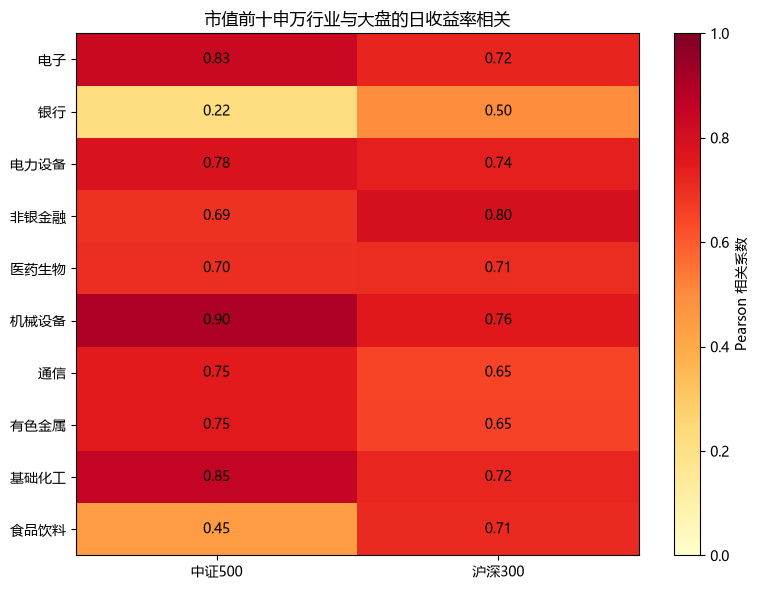

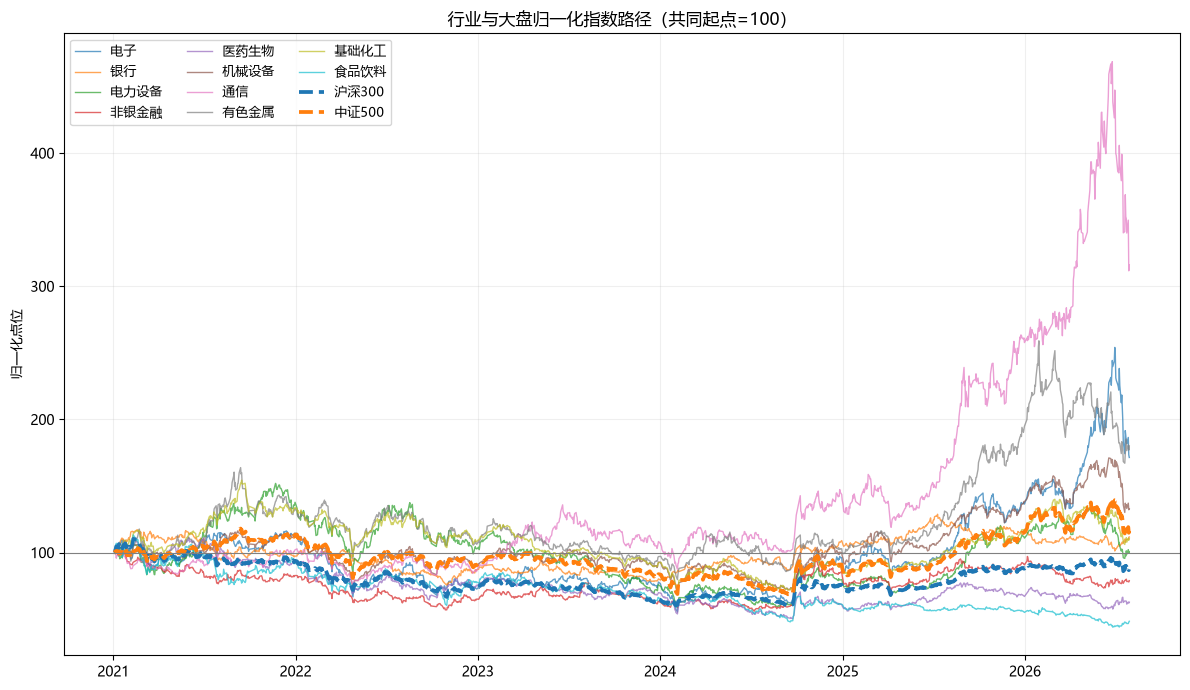

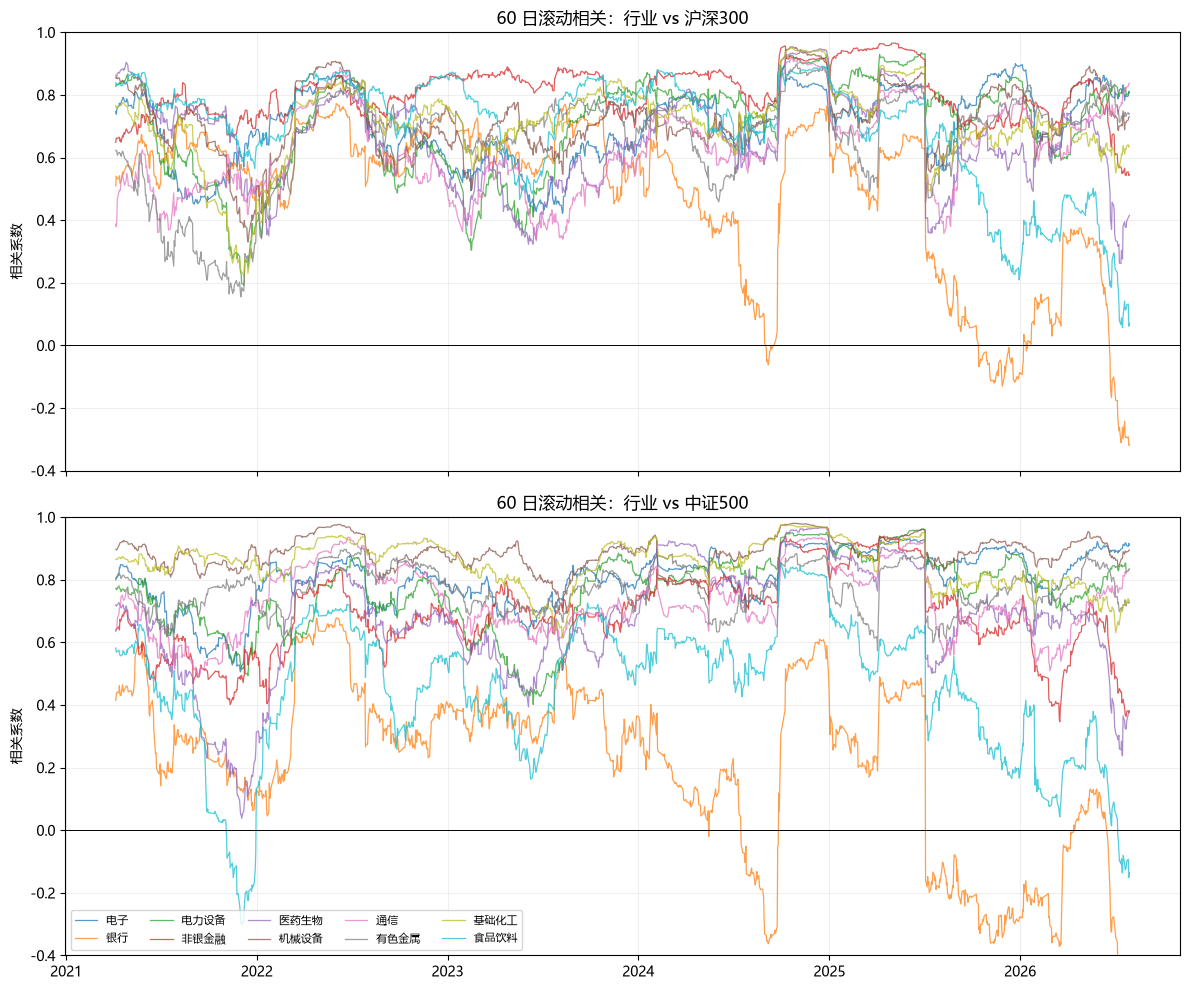

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr_matrix.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.index)), corr_matrix.index)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("市值前十申万行业与大盘的日收益率相关")
fig.colorbar(image, ax=ax, label="Pearson 相关系数")
fig.tight_layout()
fig.savefig(CHART_DIR / "correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

common_close = close_wide[industry_names + benchmark_names].dropna()
normalized = common_close / common_close.iloc[0] * 100
fig, ax = plt.subplots(figsize=(12, 7))
for industry in industry_names:
    ax.plot(normalized.index, normalized[industry], lw=1.0, alpha=0.70, label=industry)
for benchmark in benchmark_names:
    ax.plot(
        normalized.index,
        normalized[benchmark],
        lw=2.7,
        linestyle="--",
        label=benchmark,
    )
ax.axhline(100, color="gray", lw=0.8)
ax.set_title("行业与大盘归一化指数路径（共同起点=100）")
ax.set_ylabel("归一化点位")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(CHART_DIR / "normalized_trends.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for ax, benchmark in zip(axes, benchmark_names):
    for industry in industry_names:
        rolling = rolling_series[(industry, benchmark)]
        ax.plot(rolling.index, rolling.values, lw=0.9, alpha=0.75, label=industry)
    ax.axhline(0, color="black", lw=0.7)
    ax.set_ylim(-0.4, 1.0)
    ax.set_title(f"60 日滚动相关：行业 vs {benchmark}")
    ax.set_ylabel("相关系数")
    ax.grid(alpha=0.2)
axes[-1].legend(ncol=5, fontsize=8)
fig.tight_layout()
fig.savefig(CHART_DIR / "rolling_60d_correlations.png", dpi=160, bbox_inches="tight")
plt.show()


In [6]:
# 稳健性：相关排名、Pearson/Spearman差异、滚动波动范围。
robustness = metrics.copy()
robustness["pearson_spearman_gap"] = (
    robustness["pearson_corr"] - robustness["spearman_corr"]
).abs()
robustness["rolling60_range"] = (
    robustness["rolling60_max"] - robustness["rolling60_min"]
)
robustness["corr_rank_within_benchmark"] = robustness.groupby(
    "benchmark"
)["pearson_corr"].rank(ascending=False, method="min")
display(
    robustness[
        [
            "benchmark", "corr_rank_within_benchmark", "industry_name",
            "pearson_corr", "pearson_ci95_low", "pearson_ci95_high",
            "spearman_corr", "beta", "rolling60_median",
            "rolling60_min", "rolling60_max", "rolling60_latest",
            "pearson_spearman_gap",
        ]
    ].sort_values(["benchmark", "corr_rank_within_benchmark"])
    .style.format({
        "pearson_corr": "{:.3f}",
        "pearson_ci95_low": "{:.3f}",
        "pearson_ci95_high": "{:.3f}",
        "spearman_corr": "{:.3f}",
        "beta": "{:.3f}",
        "rolling60_median": "{:.3f}",
        "rolling60_min": "{:.3f}",
        "rolling60_max": "{:.3f}",
        "rolling60_latest": "{:.3f}",
        "pearson_spearman_gap": "{:.3f}",
    })
)


,benchmark,corr_rank_within_benchmark,industry_name,pearson_corr,pearson_ci95_low,pearson_ci95_high,spearman_corr,beta,rolling60_median,rolling60_min,rolling60_max,rolling60_latest,pearson_spearman_gap
11,中证500,1.000000,机械设备,0.899,0.888,0.909,0.878,1.066,0.888,0.711,0.980,0.894,0.021
17,中证500,2.000000,基础化工,0.849,0.833,0.863,0.820,0.937,0.864,0.613,0.976,0.734,0.029
1,中证500,3.000000,电子,0.835,0.818,0.850,0.796,1.245,0.815,0.506,0.931,0.911,0.039
5,中证500,4.000000,电力设备,0.779,0.757,0.799,0.760,1.122,0.792,0.402,0.963,0.835,0.019
15,中证500,5.000000,有色金属,0.751,0.727,0.774,0.738,1.094,0.768,0.573,0.903,0.727,0.013
13,中证500,6.000000,通信,0.746,0.721,0.769,0.717,1.118,0.714,0.492,0.935,0.833,0.029
9,中证500,7.000000,医药生物,0.699,0.671,0.726,0.627,0.796,0.686,0.038,0.967,0.381,0.072
7,中证500,8.000000,非银金融,0.689,0.660,0.716,0.654,0.778,0.688,0.347,0.940,0.379,0.035
19,中证500,9.000000,食品饮料,0.447,0.403,0.489,0.398,0.515,0.497,-0.301,0.854,-0.136,0.049
3,中证500,10.000000,银行,0.219,0.168,0.270,0.090,0.180,0.276,-0.542,0.678,-0.540,0.130


In [7]:
conclusions = {}
for benchmark in benchmark_names:
    subset = metrics.loc[metrics["benchmark"].eq(benchmark)].sort_values(
        "pearson_corr", ascending=False
    )
    conclusions[benchmark] = {
        "highest": subset.iloc[0]["industry_name"],
        "highest_corr": float(subset.iloc[0]["pearson_corr"]),
        "lowest": subset.iloc[-1]["industry_name"],
        "lowest_corr": float(subset.iloc[-1]["pearson_corr"]),
        "median_corr": float(subset["pearson_corr"].median()),
        "latest_rolling_median": float(subset["rolling60_latest"].median()),
    }
    print(
        f"{benchmark}: 最高 {subset.iloc[0]['industry_name']} "
        f"({subset.iloc[0]['pearson_corr']:.3f})；"
        f"最低 {subset.iloc[-1]['industry_name']} "
        f"({subset.iloc[-1]['pearson_corr']:.3f})；"
        f"前十行业中位数 {subset['pearson_corr'].median():.3f}。"
    )

result_manifest = {
    "schema_version": "1.0",
    "analysis_window": {
        "start": START_DATE.date().isoformat(),
        "end": END_DATE.date().isoformat(),
    },
    "selection": "2026-07-29 申万一级行业成分，按腾讯昨收回推总市值取前十",
    "primary_metric": "日对数收益率 Pearson 相关",
    "rolling_window": ROLLING_WINDOW,
    "top10_industries": top10[
        ["market_cap_rank", "industry_code", "industry_name", "total_mcap_yi"]
    ].to_dict("records"),
    "summary": conclusions,
    "limitations": [
        "当前市值选样回看历史，存在选择时点与幸存者偏差",
        "行业指数历史受指数编制与成分调整影响",
        "相关不等于因果或预测能力",
        "Fisher区间按独立同分布近似，未完全处理收益率时序依赖",
    ],
}
(DATA_DIR / "correlation_manifest.json").write_text(
    json.dumps(result_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

assert len(top10) == 10
assert len(metrics) == 20
assert metrics["observations"].min() >= 1_000
assert metrics["pearson_corr"].between(-1, 1).all()
assert metrics["spearman_corr"].between(-1, 1).all()
print("相关性计算与质量门禁通过")


沪深300: 最高 非银金融 (0.796)；最低 银行 (0.497)；前十行业中位数 0.716。
中证500: 最高 机械设备 (0.899)；最低 银行 (0.219)；前十行业中位数 0.749。
相关性计算与质量门禁通过


## 解释限制

- 本结果回答“当前大市值行业过去与宽基同步程度如何”，不回答“未来哪个行业会上涨”。
- 以 2026-07-29 的行业市值排序回看 2021 年以来历史，存在选择时点偏差；若用于策略，
  必须改为每期使用当时可得的成分和市值。
- 行业指数与沪深300/中证500存在成分重叠，高相关有一部分是机械性的共同持股。
- 60 日滚动相关的宽区间说明相关结构会随市场阶段变化；单一全样本系数不能当常数。
- Fisher 95% 区间用于描述抽样不确定性，但日收益率并非严格独立同分布，区间应谨慎解读。

本实验不构成投资建议。
